# (08) iP-VAE: fit w/ grad

project = ```iP-VAE```, host = ```solo```, device = ```cuda:0```

**Motivation**: <br>

This shows using separate log_lr for each neuron leads to ugly gabors.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: solo

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 10
cfg_vae['n_iters'] = 1

cfg_vae['init_scale'] = 1e-2
cfg_vae['track_stats'] = True

# cfg_tr['epochs'] = 1000
# cfg_vae['beta_inner'] = 1.0
cfg_tr['kl_beta'] = 10.0

cfg_tr['epochs'] = 600
cfg_tr['batch_size'] = 500

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.01, 'seq_len': 10, 'n_iters': 1, 'track_stats': True}

Trainer:
{'batch_size': 500, 'epochs': 600, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 10.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

poisson_vH16_t-10×1_b-1_z-[512]_<grad|lin>
b500-ep600-lr(0.002)_beta(10:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,12:11)

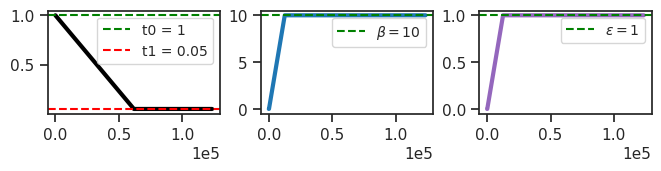

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [7]:
cm = 'replicate-2024-08/19_iterative-1.html_+per-neuron-bias-lr'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 600, avg loss: 235.478044: 100%|████| 600/600 [2:46:43<00:00, 16.67s/it]


epoch # 600, avg loss: 236.992579: 100%|████| 600/600 [2:05:05<00:00, 12.51s/it]


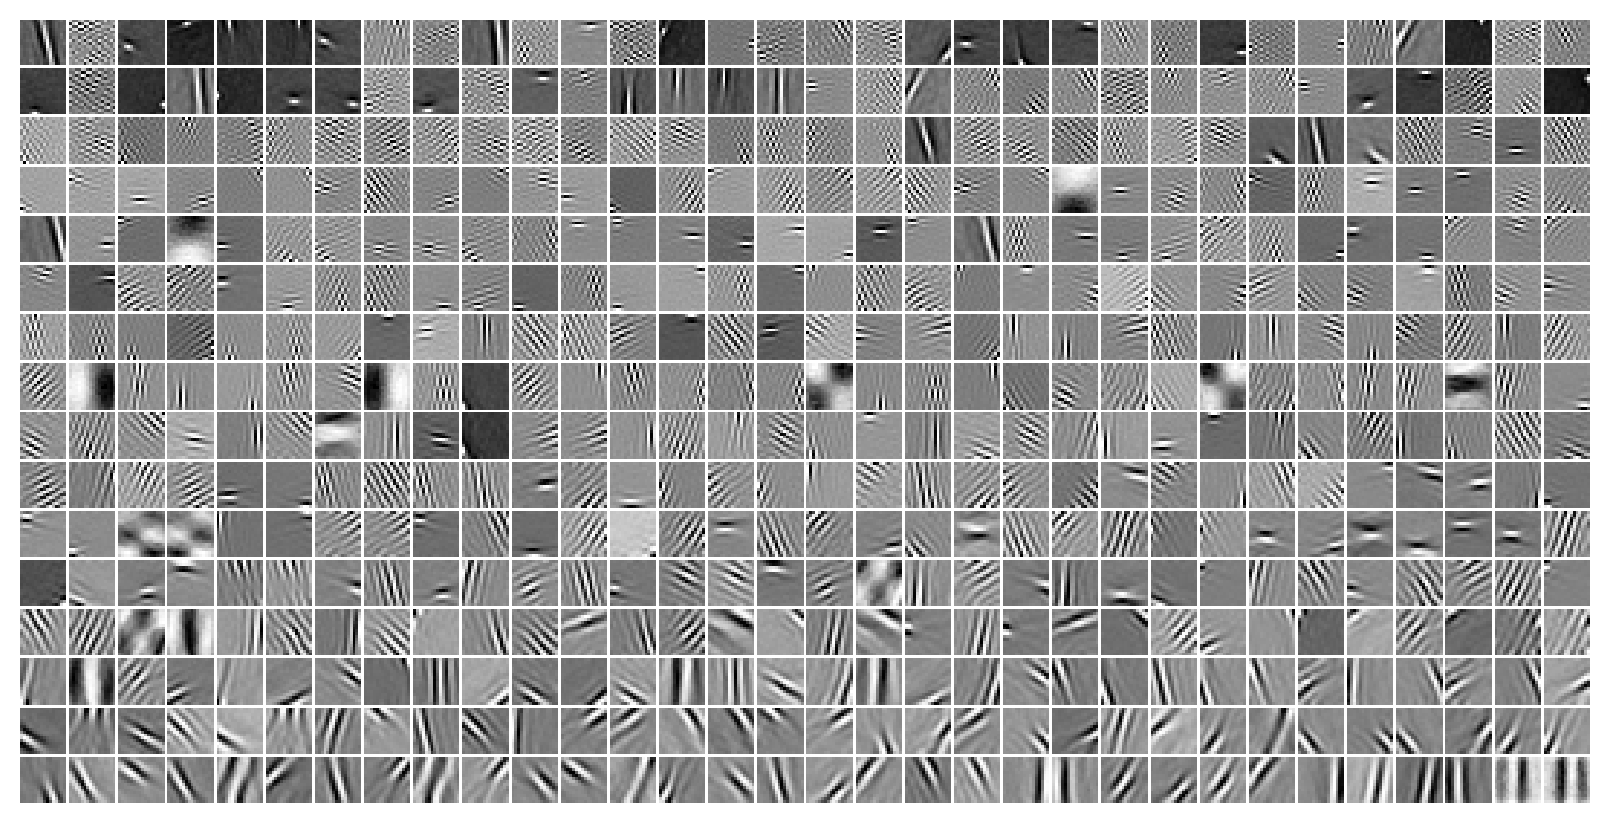

In [12]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

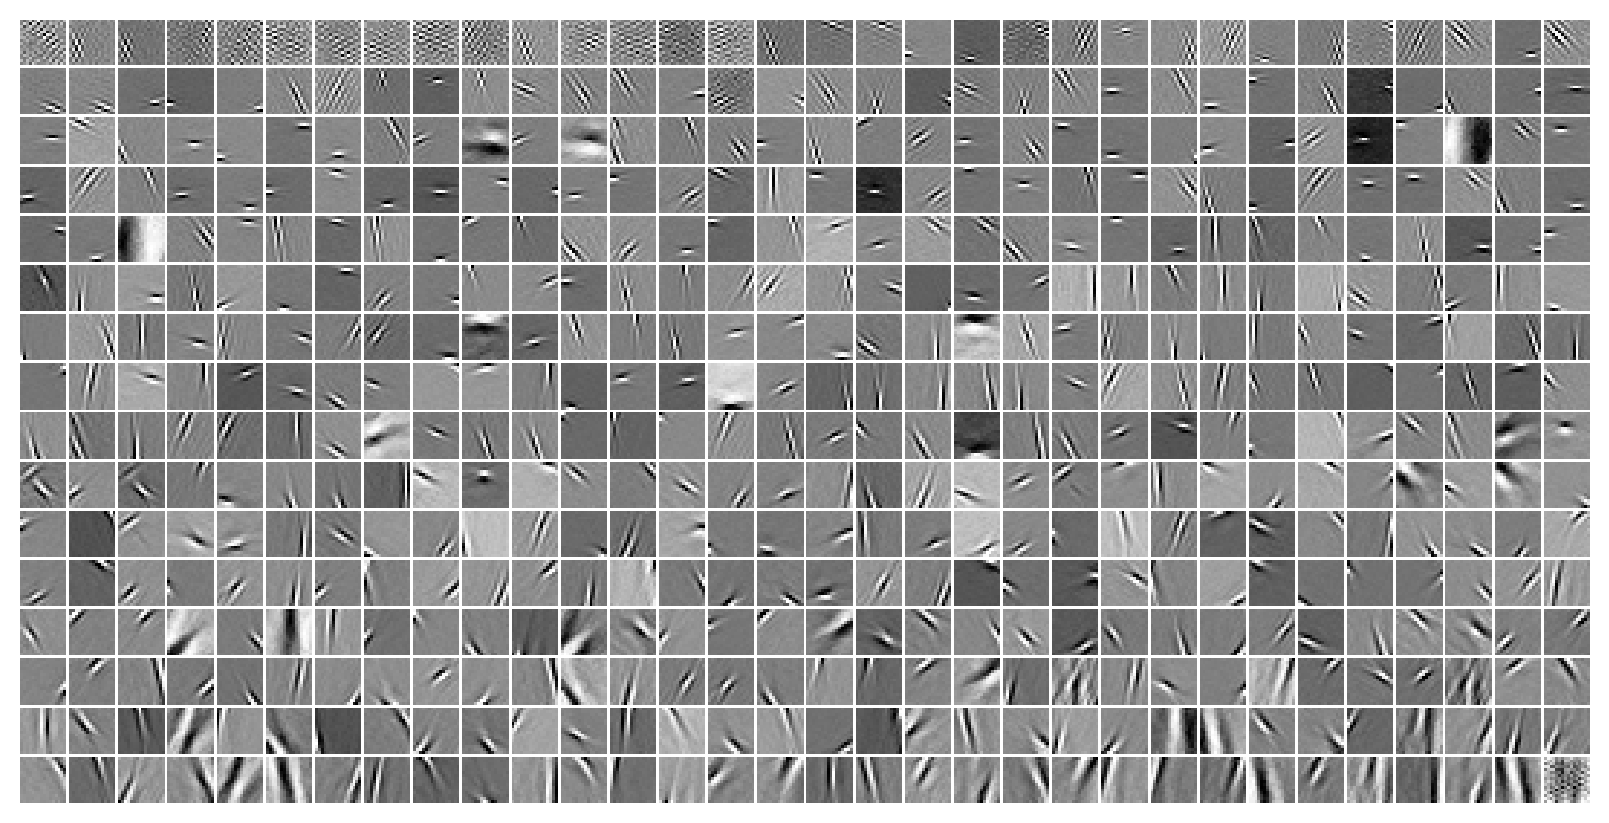

In [9]:
### Was: global (single) inner loop bias & lr

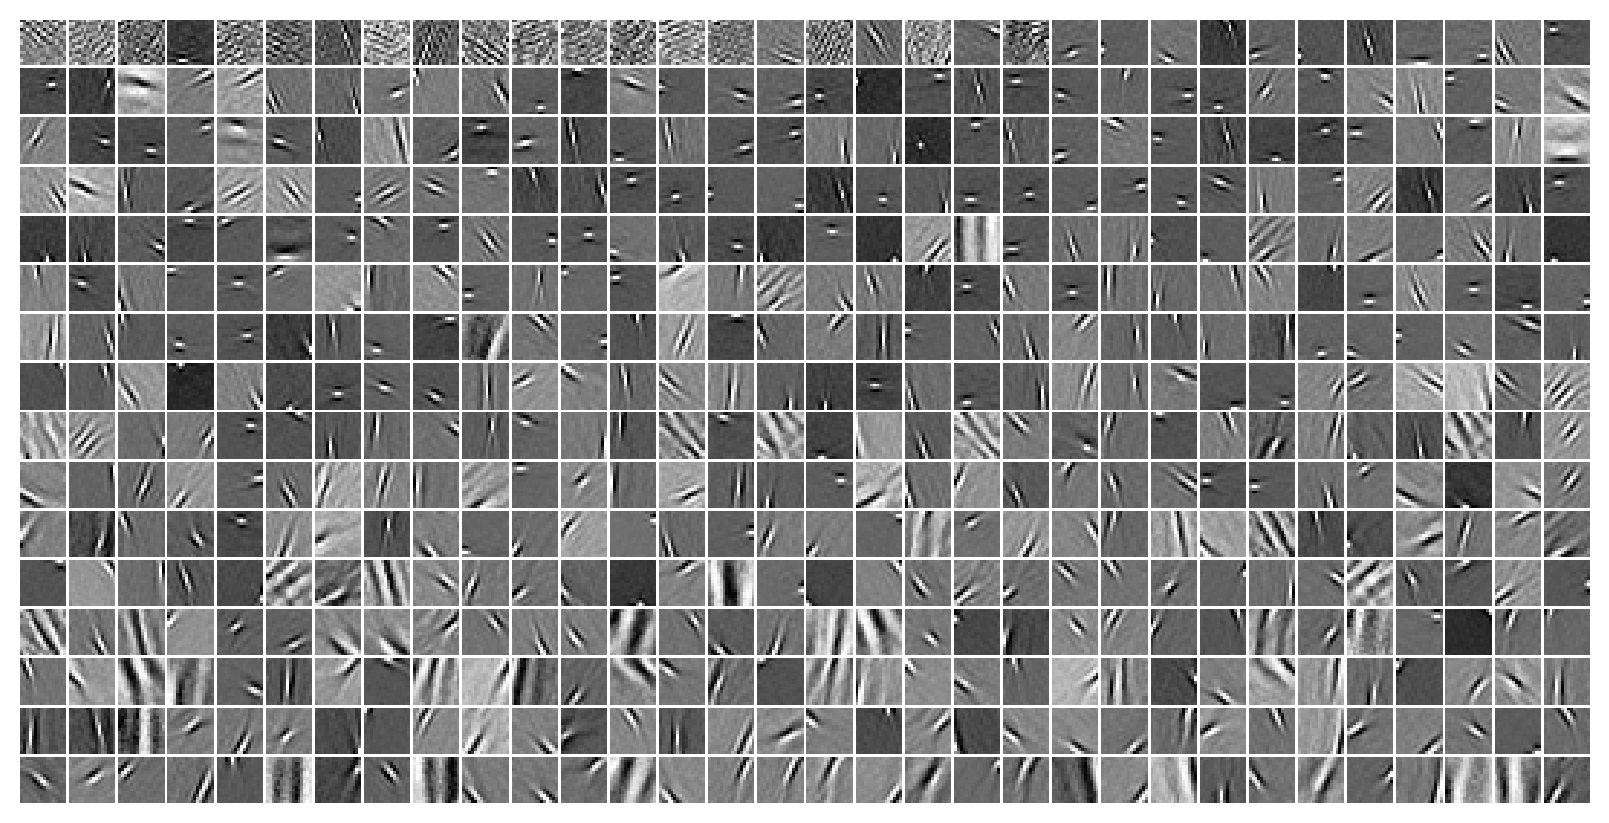

In [9]:
### Was n_iters=1, kl_beta=12.0

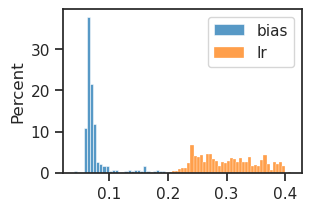

In [13]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

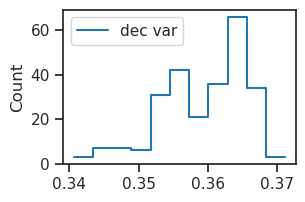

In [11]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()

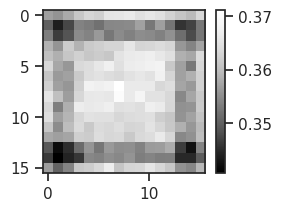

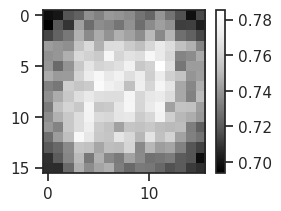

In [12]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar();

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar();

In [13]:
data, loss, etc = tr.validate()
z_last = data['z'][:, -1, :]

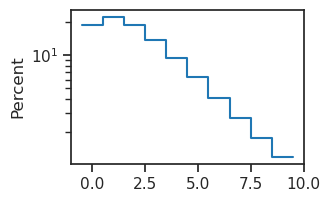

In [14]:
ax = histplot(z_last.ravel().astype(int), bins=np.linspace(0, 10, 11) - 0.5, stat='percent')
ax.set_yscale('log')

In [15]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 2.56 s, sys: 1.23 s, total: 3.78 s
Wall time: 3.78 s


[0.8521293997764587,
 0.8512099981307983,
 0.8521775007247925,
 0.8515916466712952,
 0.8513888716697693]

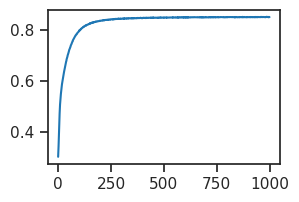

In [16]:
from analysis.sparse import sparse_score

t = 0
lifetime, population = [], []
for t in range(1000):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

In [17]:
output['loss_recon'].mean(0)[-5:]

tensor([139.9508, 139.8188, 140.0268, 140.1486, 139.6497], device='cuda:0')

In [18]:
u_norm = torch.linalg.norm(output['u'], axis=-1)
r_norm = torch.linalg.norm(torch.exp(output['u']), axis=-1)
# v_norm = torch.linalg.norm(output['v'], axis=-1)
# a_norm = torch.linalg.norm(output['a'], axis=-1)

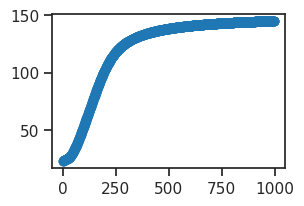

In [19]:
plot(u_norm.mean(0), marker='o');

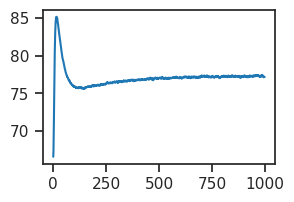

In [20]:
plot(r_norm.mean(0));

In [21]:
# plot(v_norm.mean(0), marker='o');
# plot(a_norm.mean(0), marker='o');

tensor([25.6476, 25.5508, 25.7025, 25.7894, 25.4332], device='cuda:0')

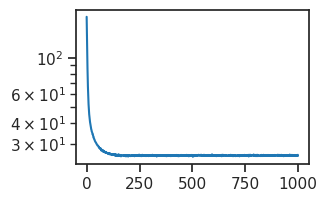

In [22]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

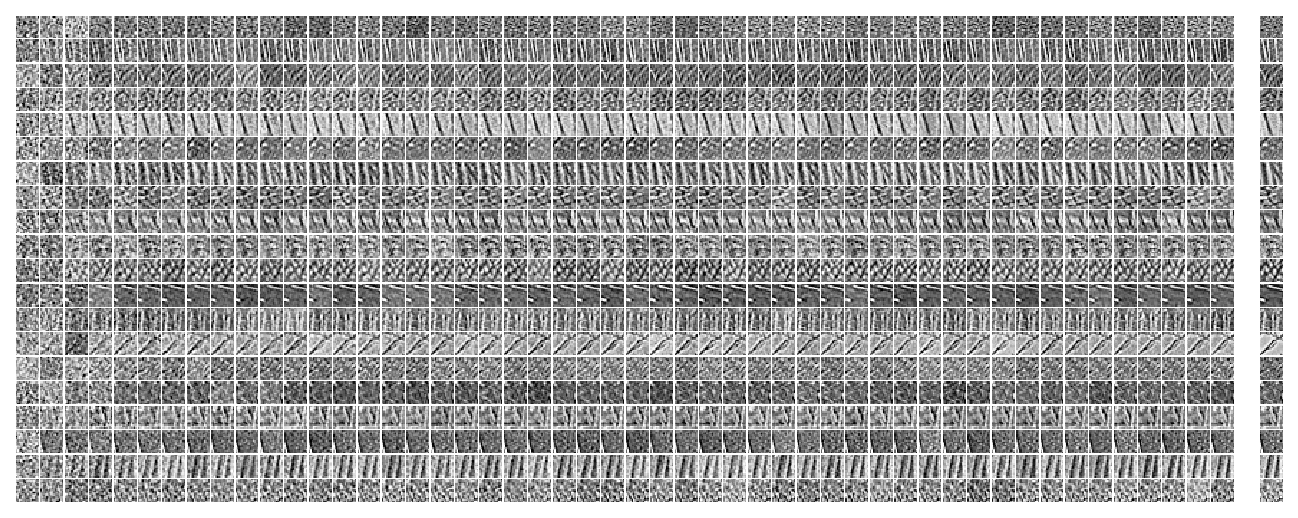

In [23]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

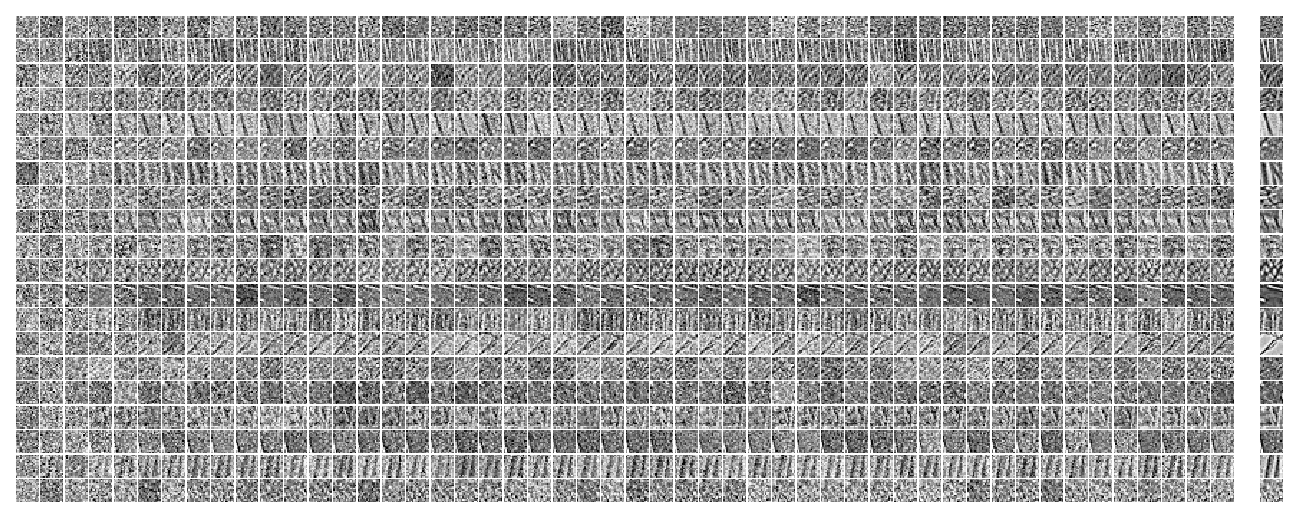

In [24]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

tensor([0.7923, 0.7928, 0.7951, 0.7884, 0.7891], device='cuda:0')

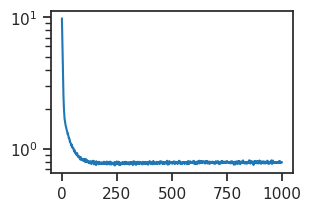

In [25]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([139.9508, 139.8188, 140.0268, 140.1486, 139.6497], device='cuda:0')

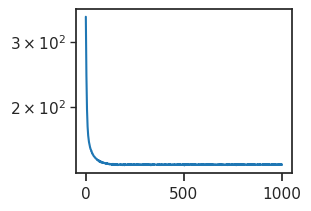

In [26]:
fig, ax = create_figure()

x2p = output['loss_recon'].mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([25.6476, 25.5508, 25.7025, 25.7894, 25.4332], device='cuda:0')

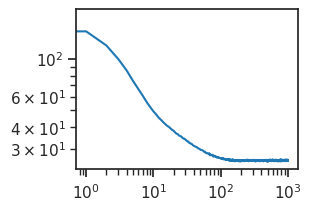

In [27]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(xscale='log', yscale='log');

x2p[-5:]

In [31]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=0.05)